# Walmart Store Sales — XGBoost Training 

In [9]:
!pip install mlflow matplotlib seaborn

In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip
/kaggle/input/datasets/nikadurishvili/walmart-preprocessing/walmart_preprocessing.py


In [11]:
import os
import sys
import json

import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
import mlflow.xgboost
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append(os.path.abspath("."))
import sys

sys.path.append("/kaggle/input/datasets/nikadurishvili/walmart-preprocessing")

from walmart_preprocessing import build_dataset

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline

print("xgboost:", xgb.__version__)
print("mlflow :", mlflow.__version__)

xgboost: 3.2.0
mlflow : 3.14.0


# Build the dataset


In [12]:
BASE_PATH = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/"
VAL_WEEKS = 8

ds = build_dataset(base_path=BASE_PATH, val_weeks=VAL_WEEKS, verbose=True)

X_tr, y_tr   = ds.X_tr, ds.y_tr
X_val, y_val = ds.X_val, ds.y_val
X_test       = ds.X_test
w_val        = ds.w_val
FEATURES     = ds.features

print(f"\nFinal feature count: {len(FEATURES)}")
print(f"X_tr={X_tr.shape}  X_val={X_val.shape}  X_test={X_test.shape}")

Step 1/7 · Loading raw data…
  train=(421570, 5)  test=(115064, 4)  stores=(45, 3)  features=(8190, 12)
Step 2/7 · Merging tables…
  Combined shape: (536634, 17)
Step 3/7 · Creating train / val / test masks…
  Train=397,841  Val=23,729  Test=115,064
Step 4/7 · Cleaning target (train only)…
  Post-clean range: -25.9 – 283,843.0
Step 5/7 · Engineering features…
  Columns after feature engineering: 135
Step 6/7 · Cleaning features…
  Features after cleaning: 82
Step 7/7 · Selecting features…
[select_features] |r| > 0.9 vs target — review:
  roll_max_52w                                   r=0.9256
  Final feature count: 67

  X_tr=(397841, 67)  X_val=(23729, 67)  X_test=(115064, 67)
  Done ✓

Final feature count: 67
X_tr=(397841, 67)  X_val=(23729, 67)  X_test=(115064, 67)


## Evaluation metric — WMAE



In [13]:
def wmae(y_true, y_pred, weights):
    return np.average(np.abs(np.asarray(y_true) - np.asarray(y_pred)), weights=weights)

w_tr = (
    ds.df.loc[ds.tr_mask, "IsHoliday"]
    .astype(float)
    .map({1.0: 5.0, 0.0: 1.0})
    .reset_index(drop=True)
)

In [ ]:
def safe_log1p(y):
    return np.log1p(np.clip(y, a_min=0, a_max=None))

y_tr_log  = safe_log1p(y_tr.values)
y_val_log = safe_log1p(y_val.values)

## MLflow experiment setup

In [14]:
!pip install dagshub

In [15]:
import dagshub
import mlflow

dagshub.init(
    repo_owner="nikaduri",
    repo_name="ml-store-sales-forecasting",
    mlflow=True,
)

EXPERIMENT_NAME = "xgboost_training"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment:   {EXPERIMENT_NAME}")

Initialized MLflow to track repo "nikaduri/ml-store-sales-forecasting"

Repository nikaduri/ml-store-sales-forecasting initialized!

Tracking URI: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow
Experiment:   xgboost_training


## Randomized hyperparameter search


In [16]:
from sklearn.model_selection import ParameterSampler
from scipy.stats import randint, uniform

N_SEARCH_ITER = 25          # how many random configs to try — raise/lower for time budget
RANDOM_SEARCH_SEED = 42

param_distributions = {
    "max_depth": randint(4, 11),
    "learning_rate": uniform(0.01, 0.09),      # 0.01 - 0.10
    "n_estimators": randint(500, 3001),
    "subsample": uniform(0.6, 0.35),           # 0.60 - 0.95
    "colsample_bytree": uniform(0.5, 0.45),    # 0.50 - 0.95
    "min_child_weight": randint(1, 8),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.5, 2.5),
    "gamma": uniform(0.0, 0.3),
}

INT_PARAMS = {"max_depth", "n_estimators", "min_child_weight"}

sampled_params = list(ParameterSampler(
    param_distributions, n_iter=N_SEARCH_ITER, random_state=RANDOM_SEARCH_SEED
))

HYPERPARAM_CONFIGS = [
    {
        "run_name": f"search_{i:02d}",
        "params": {k: (int(v) if k in INT_PARAMS else float(round(v, 4)))
                   for k, v in p.items()},
    }
    for i, p in enumerate(sampled_params)
]

print(f"Sampled {len(HYPERPARAM_CONFIGS)} random hyperparameter configurations:")
for cfg in HYPERPARAM_CONFIGS[:5]:
    print(" ", cfg["run_name"], cfg["params"])
print("  ...")


## Training loop — one MLflow run per sampled configuration

Same training logic as before (log1p target, GPU, early stopping, batched
curve logging) — just looped over the randomly sampled configs above instead
of a hand-picked list.


In [17]:
EARLY_STOPPING_ROUNDS = 50

import time
from mlflow.entities import Metric

def log_curve_batched(key, values, run_id, chunk_size=1000):
    ts = int(time.time() * 1000)
    metrics = [Metric(key=key, value=float(v), timestamp=ts, step=i)
               for i, v in enumerate(values)]
    client = mlflow.tracking.MlflowClient()
    for start in range(0, len(metrics), chunk_size):
        client.log_batch(run_id=run_id, metrics=metrics[start:start + chunk_size])

results = []
eval_histories = {}
models = {}

for cfg in HYPERPARAM_CONFIGS:
    run_name = cfg["run_name"]
    params = cfg["params"]

    with mlflow.start_run(run_name=run_name) as run:
        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            eval_metric="mae",
            device="cuda",
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            random_state=42,
            n_jobs=-1,
            **params,
        )

        model.fit(
            X_tr, y_tr_log,
            sample_weight=w_tr,
            eval_set=[(X_tr, y_tr_log), (X_val, y_val_log)],
            verbose=False,
        )

        val_pred = np.expm1(model.predict(X_val))
        tr_pred  = np.expm1(model.predict(X_tr))

        val_wmae   = wmae(y_val.values, val_pred, w_val.values)
        train_wmae = wmae(y_tr.values, tr_pred, w_tr.values)
        val_mae    = mean_absolute_error(y_val, val_pred)
        val_rmse   = float(np.sqrt(mean_squared_error(y_val, val_pred)))
        val_r2     = r2_score(y_val, val_pred)
        tr_mae     = mean_absolute_error(y_tr, tr_pred)
        best_iter  = model.best_iteration

        # --- MLflow logging ---
        mlflow.log_params(params)
        mlflow.log_param("early_stopping_rounds", EARLY_STOPPING_ROUNDS)
        mlflow.log_param("n_features", len(FEATURES))
        mlflow.log_param("val_weeks", VAL_WEEKS)
        mlflow.log_param("best_iteration", best_iter)
        mlflow.log_param("log1p_target", True)

        mlflow.log_metric("val_wmae", val_wmae)
        mlflow.log_metric("train_wmae", train_wmae)
        mlflow.log_metric("val_mae", val_mae)
        mlflow.log_metric("val_rmse", val_rmse)
        mlflow.log_metric("val_r2", val_r2)
        mlflow.log_metric("train_mae", tr_mae)

        history = model.evals_result()
        log_curve_batched("train_mae_curve", history["validation_0"]["mae"], run.info.run_id)
        log_curve_batched("val_mae_curve", history["validation_1"]["mae"], run.info.run_id)

        mlflow.xgboost.log_model(model, artifact_path="model")

        results.append({
            "run_name": run_name,
            "run_id": run.info.run_id,
            **params,
            "best_iteration": best_iter,
            "val_wmae": val_wmae,
            "train_wmae": train_wmae,
            "val_mae": val_mae,
            "val_rmse": val_rmse,
            "val_r2": val_r2,
            "train_mae": tr_mae,
        })
        eval_histories[run_name] = history
        models[run_name] = model

        print(f"[{run_name:18s}] val_wmae={val_wmae:8.2f}  train_wmae={train_wmae:8.2f}  "
              f"gap={val_wmae - train_wmae:8.2f}  val_r2={val_r2:.4f}  best_iter={best_iter}")

results_df = pd.DataFrame(results).sort_values("val_wmae").reset_index(drop=True)
results_df

2026/07/02 12:04:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[baseline          ] val_wmae= 1345.23  val_mae= 1280.26  val_rmse= 2590.54  val_r2=0.9859  best_iter=981
🏃 View run baseline at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/0/runs/cc6146d6080e4f3a9b42519744b53116
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/0


2026/07/02 12:05:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[deeper_trees      ] val_wmae= 1281.62  val_mae= 1228.30  val_rmse= 2533.45  val_r2=0.9865  best_iter=261
🏃 View run deeper_trees at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/0/runs/7e0b089da2234caab89b2b74481caf45
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/0


2026/07/02 12:06:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

2026/07/02 12:08:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[low_lr_many_trees ] val_wmae= 1328.68  val_mae= 1270.96  val_rmse= 2561.11  val_r2=0.9862  best_iter=2999
🏃 View run low_lr_many_trees at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/0/runs/5ac040cca5c74a85b458a0a764fa9136
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/0


2026/07/02 12:09:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[high_capacity     ] val_wmae= 1255.82  val_mae= 1205.92  val_rmse= 2516.61  val_r2=0.9867  best_iter=291
🏃 View run high_capacity at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/0/runs/92ab3fdee43f41908b5aa8c2cfcaf480
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/0


,run_name,run_id,train_wmae,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda,gamma,best_iteration,val_wmae,val_mae,val_rmse,val_r2,train_mae
0,high_capacity,92ab3fdee43f41908b5aa8c2cfcaf480,883.0807,1200,10,0.0400,0.8500,0.6000,1,0.0000,0.5000,0.0000,291,1255.8246,1205.9193,2516.6073,0.9867,920.4746
1,deeper_trees,7e0b089da2234caab89b2b74481caf45,990.3509,1000,9,0.0500,0.8000,0.8000,1,0.0000,1.0000,0.0000,261,1281.6183,1228.2951,2533.4544,0.9865,1020.5241
2,regularized,593bdb1de1804c4b9efee3d5cd63b3c0,1151.3039,1500,7,0.0300,0.7000,0.7000,5,0.5000,2.0000,0.1000,691,1302.3034,1243.0761,2524.5206,0.9866,1164.7899
3,low_lr_many_trees,5ac040cca5c74a85b458a0a764fa9136,1192.2572,3000,6,0.0100,0.8000,0.8000,2,0.1000,1.5000,0.0500,2999,1328.6838,1270.9582,2561.1069,0.9862,1200.3850
4,baseline,cc6146d6080e4f3a9b42519744b53116,1109.9918,1000,6,0.0500,0.8000,0.8000,1,0.0000,1.0000,0.0000,981,1345.2255,1280.2559,2590.5422,0.9859,1129.2633
5,shallow_fast_lr,90ab24cdd12443b5936dcc86d1189306,1232.7627,2000,4,0.1000,0.9000,0.9000,3,0.0000,1.0000,0.0000,1420,1388.0985,1316.7186,2589.6192,0.9859,1242.7483


## Results table

In [18]:
display_cols = ["run_name", "val_wmae", "train_wmae", "val_mae", "val_rmse", "val_r2",
                 "best_iteration", "max_depth", "learning_rate", "n_estimators",
                 "subsample", "colsample_bytree", "reg_alpha", "reg_lambda"]
results_df[display_cols].head(15)


,run_name,val_wmae,val_mae,val_rmse,val_r2,train_mae,best_iteration,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,reg_alpha,reg_lambda
0,high_capacity,1255.8246,1205.9193,2516.6073,0.9867,920.4746,291,10,0.0400,1200,0.8500,0.6000,0.0000,0.5000
1,deeper_trees,1281.6183,1228.2951,2533.4544,0.9865,1020.5241,261,9,0.0500,1000,0.8000,0.8000,0.0000,1.0000
2,regularized,1302.3034,1243.0761,2524.5206,0.9866,1164.7899,691,7,0.0300,1500,0.7000,0.7000,0.5000,2.0000
3,low_lr_many_trees,1328.6838,1270.9582,2561.1069,0.9862,1200.3850,2999,6,0.0100,3000,0.8000,0.8000,0.1000,1.5000
4,baseline,1345.2255,1280.2559,2590.5422,0.9859,1129.2633,981,6,0.0500,1000,0.8000,0.8000,0.0000,1.0000
5,shallow_fast_lr,1388.0985,1316.7186,2589.6192,0.9859,1242.7483,1420,4,0.1000,2000,0.9000,0.9000,0.0000,1.0000


## Plot — WMAE comparison across runs

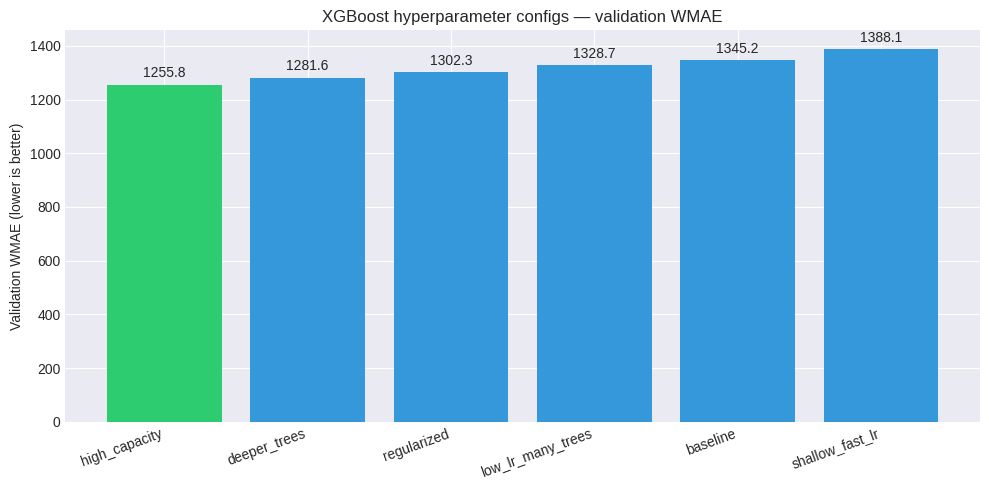

Best config: low_lr_many_trees  (run_id=5ac040cca5c74a85b458a0a764fa9136)


In [19]:
order = results_df.sort_values("val_wmae").reset_index(drop=True)
top_n = min(20, len(order))
plot_order = order.head(top_n)

fig, ax = plt.subplots(figsize=(max(10, top_n * 0.5), 5))
colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(len(plot_order))]
bars = ax.bar(plot_order["run_name"], plot_order["val_wmae"], color=colors)
ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=7)
ax.set_ylabel("Validation WMAE (lower is better)")
ax.set_title(f"Randomized search — validation WMAE (best {top_n} of {len(order)} runs)")
ax.set_xticklabels(plot_order["run_name"], rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("/tmp/plot_wmae_comparison.png", dpi=150)
plt.show()

# results_df is already sorted ascending by val_wmae, so row 0 is the winner
BEST_RUN_NAME = results_df.iloc[0]["run_name"]
BEST_RUN_ID   = results_df.iloc[0]["run_id"]
print(f"Best config: {BEST_RUN_NAME}  (run_id={BEST_RUN_ID})")
print(results_df.iloc[0][["val_wmae", "train_wmae", "max_depth", "learning_rate",
                           "n_estimators", "subsample", "colsample_bytree",
                           "reg_alpha", "reg_lambda", "gamma"]])


## Plot — learning curves (train vs val MAE), top configs

With 25 random configs a full grid is unreadable, so this shows the top
`TOP_N_CURVES` runs by validation WMAE.


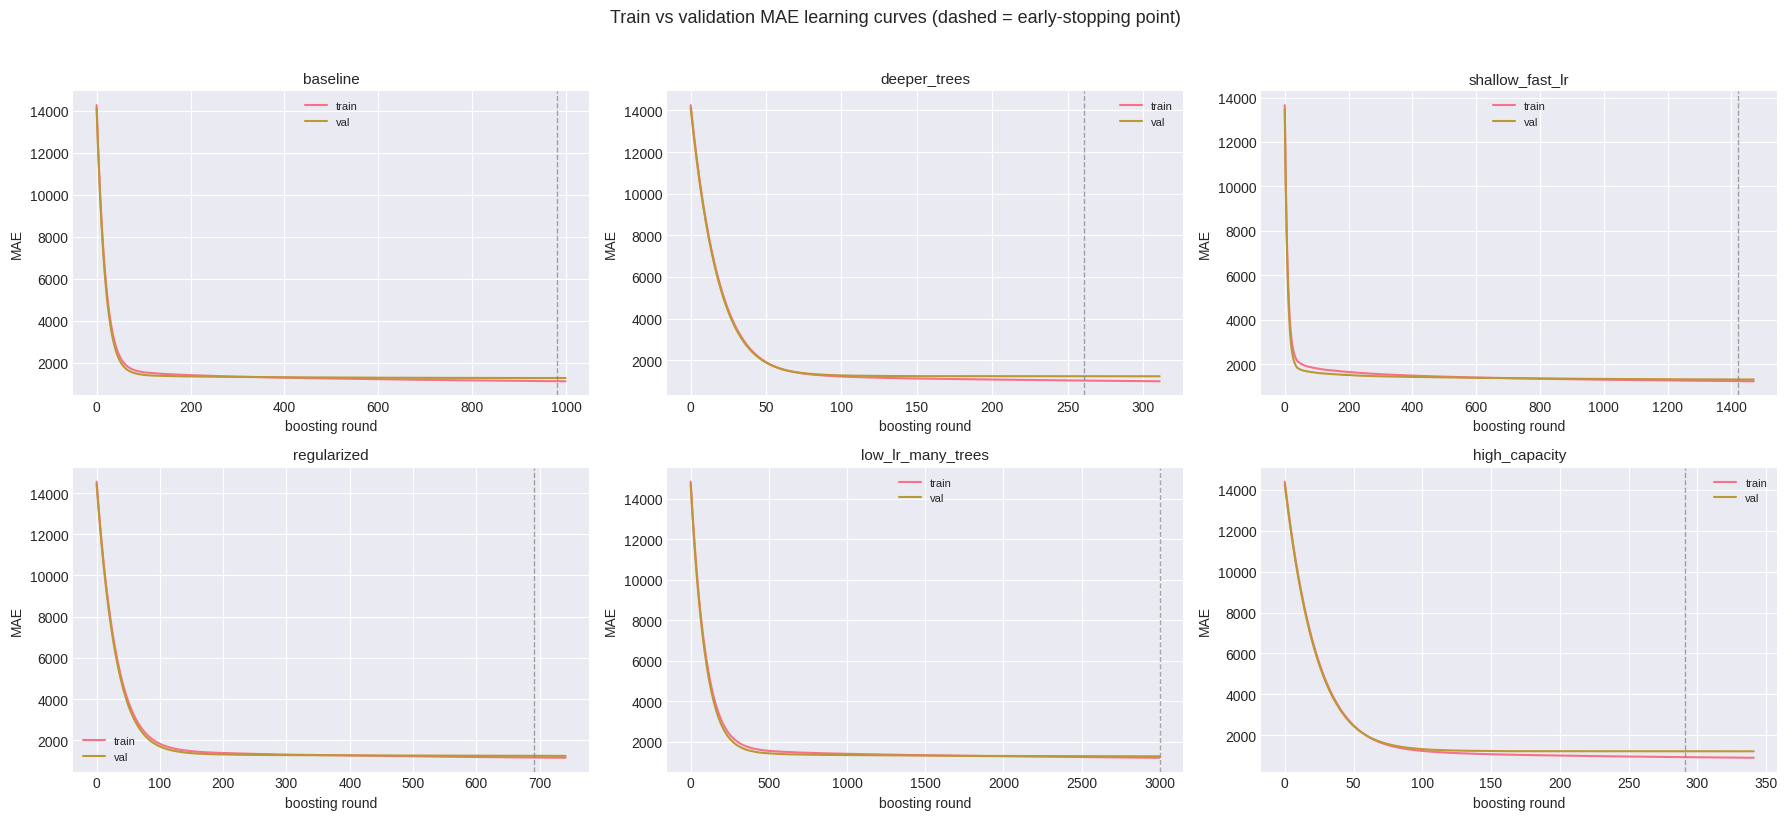

In [20]:
TOP_N_CURVES = 6
top_runs = results_df.sort_values("val_wmae").head(TOP_N_CURVES)["run_name"].tolist()

ncols = 3
nrows = int(np.ceil(TOP_N_CURVES / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=False)
axes = np.array(axes).reshape(-1)

for i, run_name in enumerate(top_runs):
    hist = eval_histories[run_name]
    ax = axes[i]
    ax.plot(hist["validation_0"]["mae"], label="train (log-space MAE)", lw=1.5)
    ax.plot(hist["validation_1"]["mae"], label="val (log-space MAE)", lw=1.5)
    best_it = models[run_name].best_iteration
    ax.axvline(best_it, color="gray", ls="--", lw=1, alpha=0.7)
    ax.set_title(run_name, fontsize=11)
    ax.set_xlabel("boosting round")
    ax.set_ylabel("MAE (log1p space)")
    ax.legend(fontsize=8)

for j in range(TOP_N_CURVES, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Train vs validation MAE — top {TOP_N_CURVES} configs by val WMAE "
             "(dashed = early-stopping point)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("/tmp/plot_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Plot — best model: actual vs predicted, and residuals

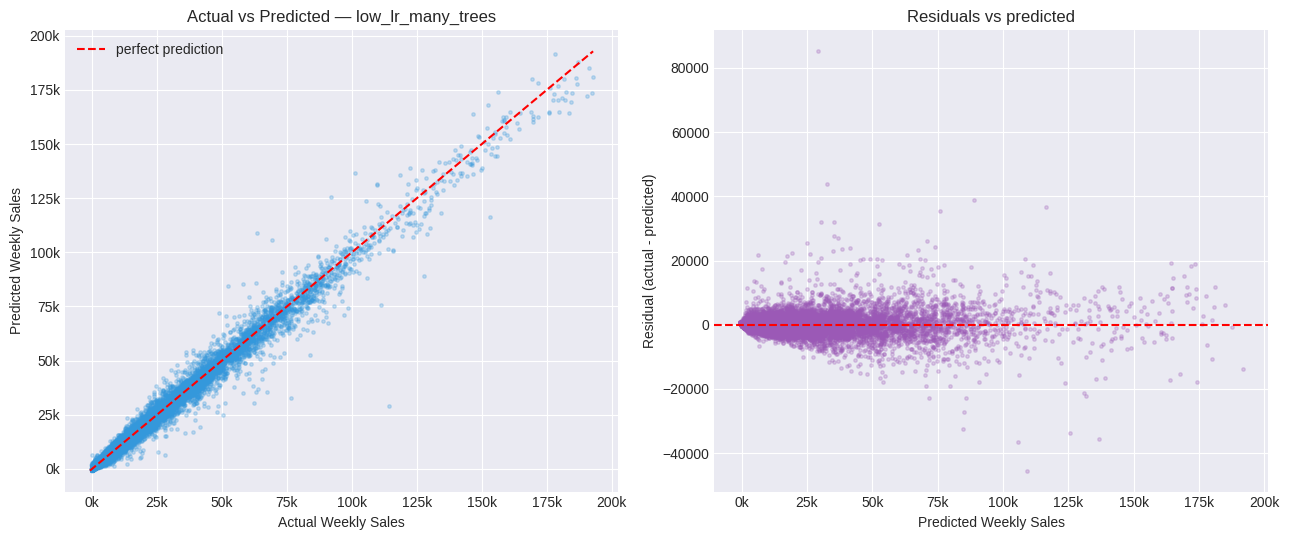

Residual mean: 40.31   Residual std: 2560.79


In [22]:
best_model = models[BEST_RUN_NAME]

# model was trained on log1p(target) — must invert before comparing to real-scale y_val
best_val_pred = np.expm1(best_model.predict(X_val))
residuals = y_val.values - best_val_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.scatter(y_val, best_val_pred, s=6, alpha=0.25, color="#3498db")
lims = [min(y_val.min(), best_val_pred.min()), max(y_val.max(), best_val_pred.max())]
ax.plot(lims, lims, color="red", lw=1.5, ls="--", label="perfect prediction")
ax.set_xlabel("Actual Weekly Sales")
ax.set_ylabel("Predicted Weekly Sales")
ax.set_title(f"Actual vs Predicted — {BEST_RUN_NAME}")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

ax = axes[1]
ax.scatter(best_val_pred, residuals, s=6, alpha=0.25, color="#9b59b6")
ax.axhline(0, color="red", lw=1.5, ls="--")
ax.set_xlabel("Predicted Weekly Sales")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residuals vs predicted")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.tight_layout()
plt.savefig("/tmp/plot_actual_vs_pred.png", dpi=150)
plt.show()

print(f"Residual mean: {residuals.mean():.2f}   Residual std: {residuals.std():.2f}")


## 10. Plot — feature importance (best model)

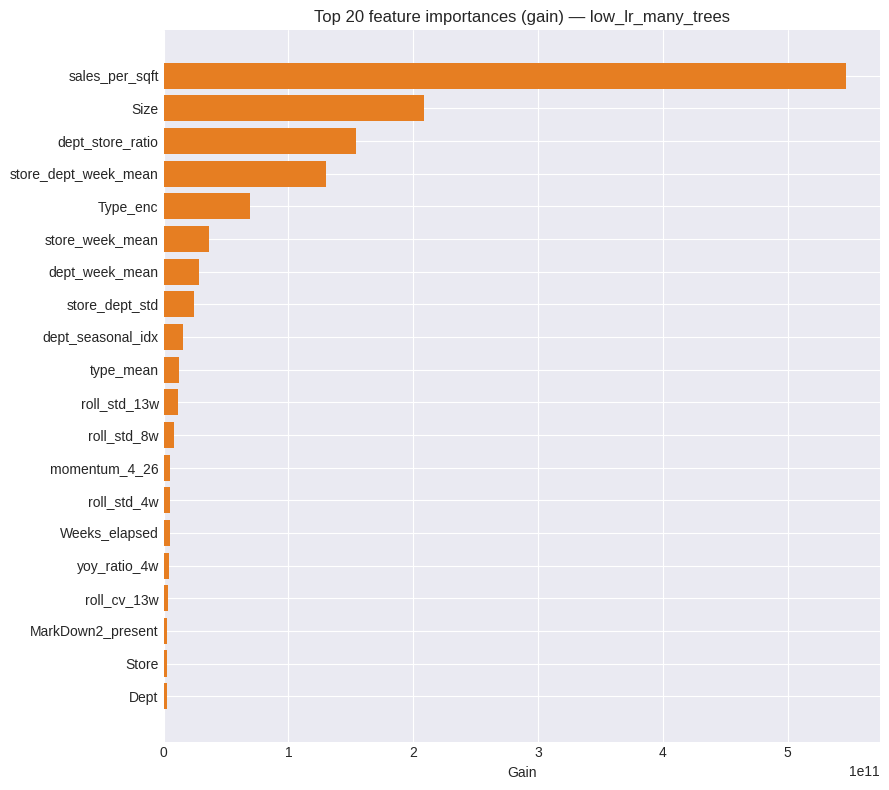

In [23]:
importances = pd.Series(
    best_model.get_booster().get_score(importance_type="gain"),
).sort_values(ascending=False)
importances = importances.head(20)[::-1]  # reverse for horizontal bar top-to-bottom

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(importances.index, importances.values, color="#e67e22")
ax.set_xlabel("Gain")
ax.set_title(f"Top 20 feature importances (gain) — {BEST_RUN_NAME}")
plt.tight_layout()
plt.savefig("/tmp/plot_feature_importance.png", dpi=150)
plt.show()

## Plot — hyperparameter sensitivity

Validation WMAE against each hyperparameter across all sampled configs —
with real random sampling instead of a handful of hand-picked presets, this
scatter is now an actual trend, not six confounded points.


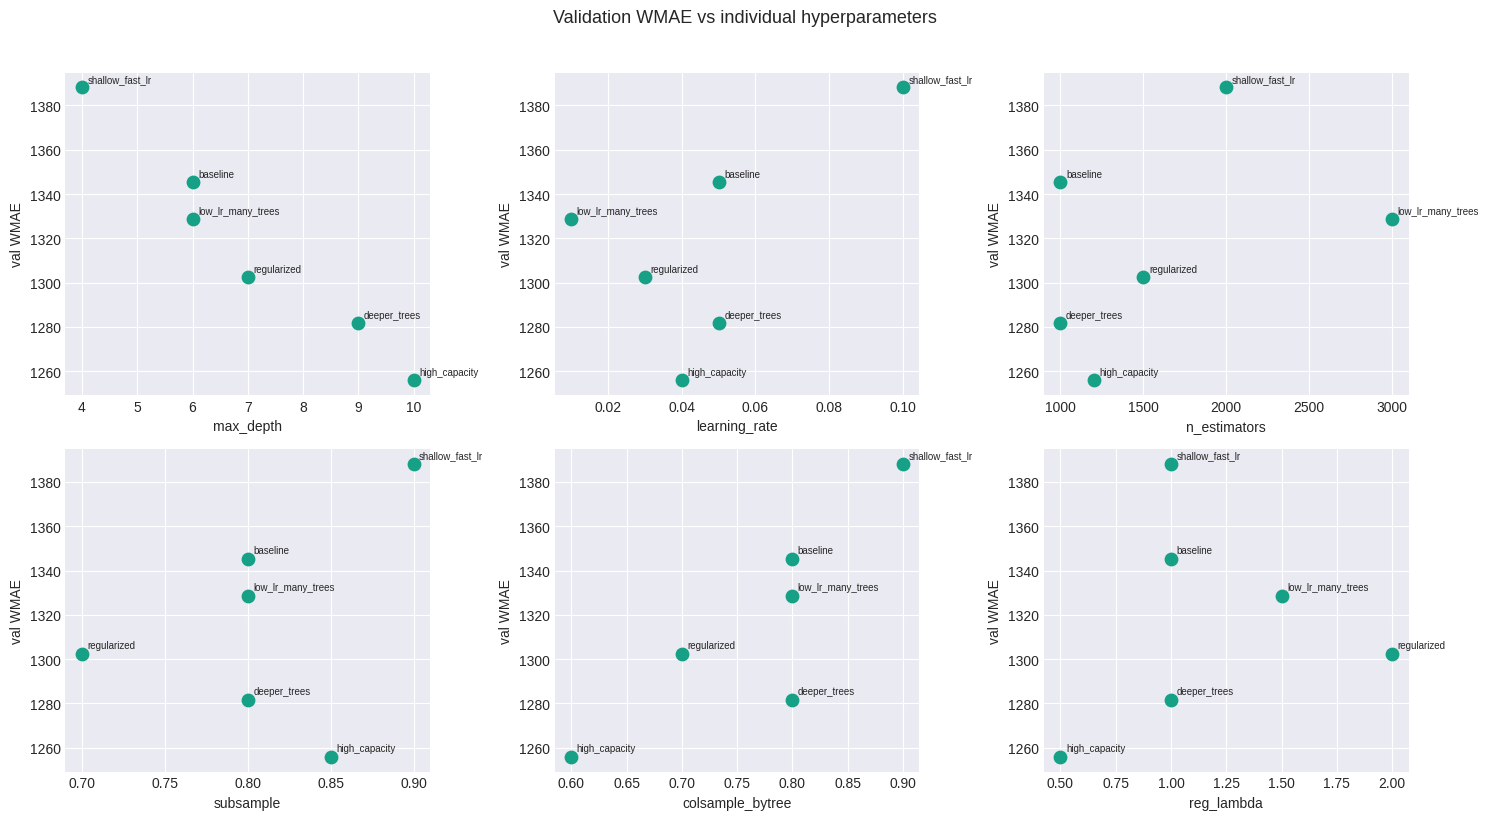

In [24]:
hp_cols = ["max_depth", "learning_rate", "n_estimators", "subsample",
           "colsample_bytree", "reg_lambda"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.reshape(-1)

best_idx = results_df["val_wmae"].idxmin()

for ax, col in zip(axes, hp_cols):
    ax.scatter(results_df[col], results_df["val_wmae"], s=40, alpha=0.6, color="#16a085")
    ax.scatter(results_df.loc[best_idx, col], results_df.loc[best_idx, "val_wmae"],
               s=140, color="#e74c3c", marker="*", zorder=5, label="best")
    ax.set_xlabel(col)
    ax.set_ylabel("val WMAE")
    ax.legend(fontsize=8)

fig.suptitle("Validation WMAE vs individual hyperparameters — all sampled configs",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("/tmp/plot_hyperparam_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()


## Plot — overfitting gap (train WMAE vs val WMAE)

Lowest `val_wmae` alone can reward a config that's just memorizing train harder. This plots `val_wmae - train_wmae` against `val_wmae` for every sampled config, so you can pick a model that's both accurate and not obviously overfit.

In [ ]:
results_df["gap"] = results_df["val_wmae"] - results_df["train_wmae"]

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(results_df["val_wmae"], results_df["gap"],
                 c=results_df["max_depth"], cmap="viridis", s=70, alpha=0.85)
ax.scatter(results_df.loc[best_idx, "val_wmae"], results_df.loc[best_idx, "gap"],
           s=200, facecolors="none", edgecolors="red", linewidths=2, label="best (lowest val_wmae)")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("max_depth")
ax.set_xlabel("Validation WMAE (lower is better)")
ax.set_ylabel("Overfitting gap: val_wmae - train_wmae (lower is better)")
ax.set_title("Accuracy vs overfitting across all sampled configs")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/plot_overfit_gap.png", dpi=150)
plt.show()

print("Top 5 by val_wmae:")
print(results_df.sort_values("val_wmae")[["run_name", "val_wmae", "gap"]].head())
print("\nTop 5 by smallest gap (most robust):")
print(results_df.sort_values("gap")[["run_name", "val_wmae", "gap"]].head())


## 12. Log a summary run to MLflow

Bundles the results table and every comparison plot as artifacts on a dedicated
`summary` run, and tags it with the winning run's id so it's easy to find later.

In [25]:
with mlflow.start_run(run_name="summary") as summary_run:
    mlflow.set_tag("best_run_name", BEST_RUN_NAME)
    mlflow.set_tag("best_run_id", BEST_RUN_ID)
    mlflow.set_tag("search_type", "randomized")
    mlflow.log_param("n_search_iter", N_SEARCH_ITER)
    mlflow.log_metric("best_val_wmae", float(results_df.iloc[0]["val_wmae"]))
    mlflow.log_metric("best_gap", float(results_df.iloc[0]["gap"]))

    results_csv_path = "/tmp/xgboost_training_results.csv"
    results_df.to_csv(results_csv_path, index=False)
    mlflow.log_artifact(results_csv_path)

    for p in [
        "/tmp/plot_wmae_comparison.png",
        "/tmp/plot_learning_curves.png",
        "/tmp/plot_actual_vs_pred.png",
        "/tmp/plot_feature_importance.png",
        "/tmp/plot_hyperparam_sensitivity.png",
        "/tmp/plot_overfit_gap.png",
    ]:
        mlflow.log_artifact(p)

    print(f"Summary run logged: {summary_run.info.run_id}")

print("\nAll runs are under the MLflow experiment 'xgboost_training'.")


Summary run logged: 3dcec7baf2504ba4ab58ead02e088ac4
🏃 View run summary at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/0/runs/3dcec7baf2504ba4ab58ead02e088ac4
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/0

All runs are under the MLflow experiment 'xgboost_training'.
Launch the UI with:  mlflow ui --backend-store-uri ./mlruns


## Talking points

A few things worth calling out once this has actually run against your data:

- **WMAE comparison bar chart** — how much the best random-search config beats the rest,
  and how tight the pack is near the top. A tight cluster near the best score suggests
  you're near a performance ceiling for this feature set; a long tail means some sampled
  configs were just bad draws.
- **Learning curves (top configs)** — curves are now in log1p space, so compare shape
  (train/val gap) rather than raw magnitude against the earlier non-log runs.
- **Actual vs predicted / residuals** — check whether the log1p transform visibly tightened
  the residual fan-out at high predicted values compared to the earlier raw-target model,
  and whether the large single outlier from before is less extreme now.
- **Feature importance** — check whether `roll_max_52w` still dominates gain, or whether
  removing it (if you added it to `LEAKY_HIGH_CORR` in the preprocessor) let other seasonal
  and holiday features contribute more.
- **Hyperparameter sensitivity scatter** — now a real trend across ~25 random draws instead
  of 6 confounded presets, so trust this one more for deciding which knob to prioritize in
  a follow-up, narrower search.
- **Overfitting gap plot** — the best point by `val_wmae` (red circle) isn't automatically
  the best choice if a nearby point has a much smaller train/val gap — that's the more
  robust pick for data the model hasn't seen yet (e.g. next year's holiday season).
